In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def generate_heatmaps(input_file):
    # --- 1. File Paths and Setup ---
    OUTPUT_DIR = '0713_Heatmaps_2/'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory ready: {OUTPUT_DIR}")

    # Define the 6 columns based on the file snippet
    column_names = ['Seed', 'EI_Index', 'IE_Index', 'Power', 'Wavelet_Freq', 'ACF_Freq']

    try:
        # Load the data without headers
        data = pd.read_excel(input_file, header=None, names=column_names)
        print(f"Successfully loaded {len(data)} raw data points.")
    except FileNotFoundError:
        print(f"ERROR: File '{input_file}' not found.")
        return

    # --- 2. Data Cleaning & Filtering ---
    # Convert necessary columns to numeric to handle any potential read errors
    for col in column_names:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    
    # Drop NaNs just in case there were parsing errors
    data = data.dropna()

    # Filters
    data = data[(data['EI_Index'] >= 3) & (data['IE_Index'] >= 5)]

    # --- 3. Aggregation across Seeds ---
    # Group by the EI and IE indices, then take the mean of the remaining columns
    grouped_data = data.groupby(['EI_Index', 'IE_Index']).mean().reset_index()
    print(f"Data aggregated into {len(grouped_data)} unique coordinate pairs.")

    # --- 4. Data Transformation ---
    # Calculate Log10 of the averaged Power (protecting against log(0) with a tiny epsilon)
    grouped_data['Log_Power'] = np.log10(np.where(grouped_data['Power'] > 0, grouped_data['Power'], 1e-9))

    # --- 5. Pivot Tables (Matrix Creation) ---
    # Ensure axes are sorted properly
    ei_unique = np.sort(grouped_data['EI_Index'].unique())
    ie_unique = np.sort(grouped_data['IE_Index'].unique())

    # Create categorical types to ensure the matrix grid is strictly ordered
    grouped_data['EI_Index_C'] = pd.Categorical(grouped_data['EI_Index'], categories=ei_unique, ordered=True)
    grouped_data['IE_Index_C'] = pd.Categorical(grouped_data['IE_Index'], categories=ie_unique, ordered=True)

    # Generate the 3 Data Matrices
    matrix_power = grouped_data.pivot_table(index='IE_Index_C', columns='EI_Index_C', values='Log_Power').values
    matrix_wavelet = grouped_data.pivot_table(index='IE_Index_C', columns='EI_Index_C', values='Wavelet_Freq').values
    matrix_acf = grouped_data.pivot_table(index='IE_Index_C', columns='EI_Index_C', values='ACF_Freq').values

    # Clean integer labels for the axes
    ei_labels = [str(int(x)) for x in ei_unique]
    ie_labels = [str(int(x)) for x in ie_unique]

    # --- 6. Plotting ---
    sns.set_style("white")

    # Define the 3 requested colormaps
    colormaps = ['RdYlBu_r', 'viridis', 'plasma']

    # Define the 3 metrics we are mapping
    metrics = [
        {'data': matrix_power, 'name': 'Log_Power', 'title': 'Average Log Power', 'cbar_label': '$\log_{10}(\\text{Power})$ (a.u.)'},
        {'data': matrix_wavelet, 'name': 'Wavelet_Freq', 'title': 'Wavelet Frequency', 'cbar_label': 'Frequency (Hz)'},
        {'data': matrix_acf, 'name': 'ACF_Freq', 'title': 'ACF Frequency', 'cbar_label': 'Frequency (Hz)'}
    ]

    # Generate plots for each metric and each colormap
    for metric in metrics:
        for cmap in colormaps:
            fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

            sns.heatmap(
                metric['data'],
                ax=ax,
                cmap=cmap, 
                cbar_kws={'label': metric['cbar_label'], 'orientation': 'vertical', 'pad': 0.05, 'shrink': 0.9},
                xticklabels=ei_labels,
                yticklabels=ie_labels,
                linewidths=0.01,
                linecolor='gray',
                square=True,
                cbar=True
            )

            # Invert Y-axis so index 0 is at the bottom
            ax.invert_yaxis()

            # Clean up the visualization
            ax.set_title(f"{metric['title']} Heatmap ({cmap})", fontsize=16, pad=15)
            ax.set_xlabel('E-I Conductance Index', fontsize=14)
            ax.set_ylabel('I-E Conductance Index', fontsize=14)
            
            # Center the ticks
            ax.set_xticks(np.arange(len(ei_labels)) + 0.5, labels=ei_labels, rotation=0, fontsize=11)
            ax.set_yticks(np.arange(len(ie_labels)) + 0.5, labels=ie_labels, rotation=0, fontsize=11)

            # File naming and saving
            file_base = f"{OUTPUT_DIR}{metric['name']}_{cmap}"
            fig.savefig(f"{file_base}.png", dpi=300, bbox_inches='tight')
            fig.savefig(f"{file_base}.eps", format='eps', bbox_inches='tight')

            plt.close(fig)
            print(f"Saved: {file_base}.png / .eps")

    print("\nAll visualizations completed successfully.")

if __name__ == "__main__":
    input_filename = '0711_GEGI_Data_All.xlsx'
    generate_heatmaps(input_filename)

Output directory ready: 0713_Heatmaps_2/
Successfully loaded 4000 raw data points.
Data aggregated into 255 unique coordinate pairs.
Saved: 0713_Heatmaps_2/Log_Power_RdYlBu_r.png / .eps
Saved: 0713_Heatmaps_2/Log_Power_viridis.png / .eps
Saved: 0713_Heatmaps_2/Log_Power_plasma.png / .eps
Saved: 0713_Heatmaps_2/Wavelet_Freq_RdYlBu_r.png / .eps
Saved: 0713_Heatmaps_2/Wavelet_Freq_viridis.png / .eps
Saved: 0713_Heatmaps_2/Wavelet_Freq_plasma.png / .eps
Saved: 0713_Heatmaps_2/ACF_Freq_RdYlBu_r.png / .eps
Saved: 0713_Heatmaps_2/ACF_Freq_viridis.png / .eps
Saved: 0713_Heatmaps_2/ACF_Freq_plasma.png / .eps

All visualizations completed successfully.


In [11]:
import pandas as pd
from IPython.display import display

# 1. Load ONLY the first 6 columns
input_file = '0711_GEGI_Data_All.xlsx'
output_file = '0711_Filtered_Diagnostics.xlsx'
column_names = ['Seed', 'EI_Index', 'IE_Index', 'Power', 'Wavelet_Freq', 'ACF_Freq']

print("Loading data...")
data = pd.read_excel(input_file, header=None, names=column_names, usecols=[0, 1, 2, 3, 4, 5])

# Convert all loaded columns to numeric, coercing any errors to NaN
for col in column_names:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# --- THE NEW FILTER ---
# Drop E-I indices 0, 1, and 2 immediately so they don't end up in the calculations or sheets
data = data[data['EI_Index'] >= 3]
print(f"Filtered out E-I indices 0, 1, and 2. {len(data)} valid rows remain.")

# Calculate the Frequency Difference on the cleaned dataset
data['Freq_Diff'] = (data['Wavelet_Freq'] - data['ACF_Freq']).abs()

# ---------------------------------------------------------
# Filter 1: Frequency Difference > 20 Hz
# ---------------------------------------------------------
high_diff_data = data[data['Freq_Diff'] > 20]
print(f"\n--- Rows where Frequency Difference > 20 Hz ({len(high_diff_data)} found) ---")
display(high_diff_data)

# ---------------------------------------------------------
# Filter 2: Power < 10,000 units
# ---------------------------------------------------------
low_power_data = data[data['Power'] < 10000]
print(f"\n--- Rows where Power < 10,000 units ({len(low_power_data)} found) ---")
display(low_power_data)

# ---------------------------------------------------------
# Export to a Single Excel File with Multiple Sheets
# ---------------------------------------------------------
print(f"\nSaving filtered data to '{output_file}'...")

# Use ExcelWriter to write to multiple sheets
with pd.ExcelWriter(output_file) as writer:
    # index=False prevents pandas from writing the row numbers as a new column
    high_diff_data.to_excel(writer, sheet_name='High_Freq_Diff', index=False)
    low_power_data.to_excel(writer, sheet_name='Low_Power', index=False)

print("Export complete!")

Loading data...
Filtered out E-I indices 0, 1, and 2. 3400 valid rows remain.

--- Rows where Frequency Difference > 20 Hz (445 found) ---


,Seed,EI_Index,IE_Index,Power,Wavelet_Freq,ACF_Freq,Freq_Diff
60,0,3,0,168.26,124,62.66,61.34
61,0,3,1,508.25,118,59.74,58.26
62,0,3,2,1220.29,113,58.14,54.86
63,0,3,3,2592.37,102,53.94,48.06
81,0,4,1,708.52,124,62.85,61.15
...,...,...,...,...,...,...,...
3843,9,12,3,6814.99,86,26.65,59.35
3860,9,13,0,234.74,199,67.75,131.25
3940,9,17,0,204.52,213,48.90,164.10
3960,9,18,0,216.42,216,48.54,167.46



--- Rows where Power < 10,000 units (852 found) ---


,Seed,EI_Index,IE_Index,Power,Wavelet_Freq,ACF_Freq,Freq_Diff
60,0,3,0,168.26,124,62.66,61.34
61,0,3,1,508.25,118,59.74,58.26
62,0,3,2,1220.29,113,58.14,54.86
63,0,3,3,2592.37,102,53.94,48.06
64,0,3,4,5260.09,92,88.34,3.66
...,...,...,...,...,...,...,...
3963,9,18,3,8310.68,80,82.03,2.03
3980,9,19,0,202.99,87,49.63,37.37
3981,9,19,1,1772.17,84,82.24,1.76
3982,9,19,2,4430.59,79,71.74,7.26



Saving filtered data to '0711_Filtered_Diagnostics.xlsx'...
Export complete!


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def generate_heatmaps(input_file):
    # --- 1. File Paths and Setup ---
    OUTPUT_DIR = '0715_Heatmaps_2/'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory ready: {OUTPUT_DIR}")

    # Define the 6 columns based on the file snippet
    column_names = ['Seed', 'EI_Index', 'IE_Index', 'Power', 'Wavelet_Freq', 'ACF_Freq']

    try:
        # Load the data without headers
        data = pd.read_excel(input_file, header=None, names=column_names, usecols=[0, 1, 2, 3, 4, 5])
        print(f"Successfully loaded {len(data)} raw data points.")
    except FileNotFoundError:
        print(f"ERROR: File '{input_file}' not found.")
        return

    # --- 2. Data Cleaning & Index Filtering ---
    # Convert necessary columns to numeric to handle any potential read errors
    for col in column_names:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    
    # Drop NaNs just in case there were parsing errors
    data = data.dropna()
    initial_valid_rows = len(data)

    # Base Index Filter: EI >= 3 and IE >= 4
    data = data[(data['EI_Index'] >= 3) & (data['IE_Index'] >= 5)]
    print(f"Filtered indices (EI >= 3, IE >= 4): {len(data)} rows remain.")

    # --- 3. The 40 Hz Confidence Filter (Exclusion Method) ---
    data['Freq_Diff'] = (data['Wavelet_Freq'] - data['ACF_Freq']).abs()
    
    # Keep only rows where the difference is <= 40 Hz
    data = data[data['Freq_Diff'] <= 20]
    dropped_seeds = initial_valid_rows - len(data)
    print(f"Confidence filter applied: Dropped unstable seeds (> 40 Hz diff). {len(data)} high-confidence rows remain.")
    
    """data = data[data['Power'] >= 8000]
    dropped_seeds = initial_valid_rows - len(data)
    print(f"Confidence filter applied: Dropped low power (< 5000 units power). {len(data)} high-confidence rows remain.")
    """
    
    # --- 4. Aggregation across Seeds ---
    # Group by the EI and IE indices, then take the mean of the remaining valid seeds
    grouped_data = data.groupby(['EI_Index', 'IE_Index']).mean().reset_index()
    print(f"Data aggregated into {len(grouped_data)} unique coordinate pairs.")

    # --- 5. Data Transformation ---
    # Calculate Log10 of the averaged Power (protecting against log(0) with a tiny epsilon)
    grouped_data['Log_Power'] = np.log10(np.where(grouped_data['Power'] > 0, grouped_data['Power'], 1e-9))

    # --- 6. Pivot Tables (Matrix Creation) ---
    # Ensure axes represent the full expected grid even if some coordinates were completely dropped
    ei_unique = np.sort(grouped_data['EI_Index'].unique())
    ie_unique = np.sort(grouped_data['IE_Index'].unique())

    # Create categorical types to ensure the matrix grid is strictly ordered
    grouped_data['EI_Index_C'] = pd.Categorical(grouped_data['EI_Index'], categories=ei_unique, ordered=True)
    grouped_data['IE_Index_C'] = pd.Categorical(grouped_data['IE_Index'], categories=ie_unique, ordered=True)

    # Generate the 3 Data Matrices
    matrix_power = grouped_data.pivot_table(index='IE_Index_C', columns='EI_Index_C', values='Log_Power').values
    matrix_wavelet = grouped_data.pivot_table(index='IE_Index_C', columns='EI_Index_C', values='Wavelet_Freq').values
    matrix_acf = grouped_data.pivot_table(index='IE_Index_C', columns='EI_Index_C', values='ACF_Freq').values

    # Clean integer labels for the axes
    ei_labels = [str(int(x)) for x in ei_unique]
    ie_labels = [str(int(x)) for x in ie_unique]

    # --- 7. Plotting ---
    sns.set_style("white")

    # Define the 3 requested colormaps
    colormaps = ['RdYlBu_r', 'viridis', 'plasma']

    # Define the 3 metrics we are mapping
    metrics = [
        {'data': matrix_power, 'name': 'Log_Power', 'title': 'Average Log Power', 'cbar_label': '$\log_{10}(\\text{Power})$ (a.u.)'},
        {'data': matrix_wavelet, 'name': 'Wavelet_Freq', 'title': 'Wavelet Frequency', 'cbar_label': 'Frequency (Hz)'},
        {'data': matrix_acf, 'name': 'ACF_Freq', 'title': 'ACF Frequency', 'cbar_label': 'Frequency (Hz)'}
    ]

    # Generate plots for each metric and each colormap
    for metric in metrics:
        for cmap in colormaps:
            fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

            # Note: seaborn handles np.nan automatically by leaving the square blank
            sns.heatmap(
                metric['data'],
                ax=ax,
                cmap=cmap, 
                cbar_kws={'label': metric['cbar_label'], 'orientation': 'vertical', 'pad': 0.05, 'shrink': 0.9},
                xticklabels=ei_labels,
                yticklabels=ie_labels,
                linewidths=0.01,
                linecolor='gray',
                square=True,
                cbar=True,
                mask=np.isnan(metric['data']) # Explicitly mask NaNs for clean blank squares
            )

            # Invert Y-axis so low indices are at the bottom
            ax.invert_yaxis()

            # Clean up the visualization
            ax.set_title(f"{metric['title']} Heatmap ({cmap})", fontsize=16, pad=15)
            ax.set_xlabel('E-I Conductance Index', fontsize=14)
            ax.set_ylabel('I-E Conductance Index', fontsize=14)
            
            # Center the ticks
            ax.set_xticks(np.arange(len(ei_labels)) + 0.5, labels=ei_labels, rotation=0, fontsize=11)
            ax.set_yticks(np.arange(len(ie_labels)) + 0.5, labels=ie_labels, rotation=0, fontsize=11)

            # File naming and saving
            file_base = f"{OUTPUT_DIR}{metric['name']}_{cmap}"
            fig.savefig(f"{file_base}.png", dpi=300, bbox_inches='tight')
            fig.savefig(f"{file_base}.eps", format='eps', bbox_inches='tight')

            plt.close(fig)
            print(f"Saved: {file_base}.png / .eps")

    print("\nAll highly confident visualizations completed successfully.")

if __name__ == "__main__":
    input_filename = '0711_GEGI_Data_All.xlsx'
    generate_heatmaps(input_filename)

Output directory ready: 0715_Heatmaps_2/
Successfully loaded 4000 raw data points.
Filtered indices (EI >= 3, IE >= 4): 2550 rows remain.
Confidence filter applied: Dropped unstable seeds (> 40 Hz diff). 2509 high-confidence rows remain.
Data aggregated into 255 unique coordinate pairs.
Saved: 0715_Heatmaps_2/Log_Power_RdYlBu_r.png / .eps
Saved: 0715_Heatmaps_2/Log_Power_viridis.png / .eps
Saved: 0715_Heatmaps_2/Log_Power_plasma.png / .eps
Saved: 0715_Heatmaps_2/Wavelet_Freq_RdYlBu_r.png / .eps
Saved: 0715_Heatmaps_2/Wavelet_Freq_viridis.png / .eps
Saved: 0715_Heatmaps_2/Wavelet_Freq_plasma.png / .eps
Saved: 0715_Heatmaps_2/ACF_Freq_RdYlBu_r.png / .eps
Saved: 0715_Heatmaps_2/ACF_Freq_viridis.png / .eps
Saved: 0715_Heatmaps_2/ACF_Freq_plasma.png / .eps

All highly confident visualizations completed successfully.


Data loaded successfully.
Sliced data for EI_Index = 15. 200 rows remain.
Filters applied (IE >= 5, Diff <= 10Hz). Retained 150 highly confident rows for plotting.


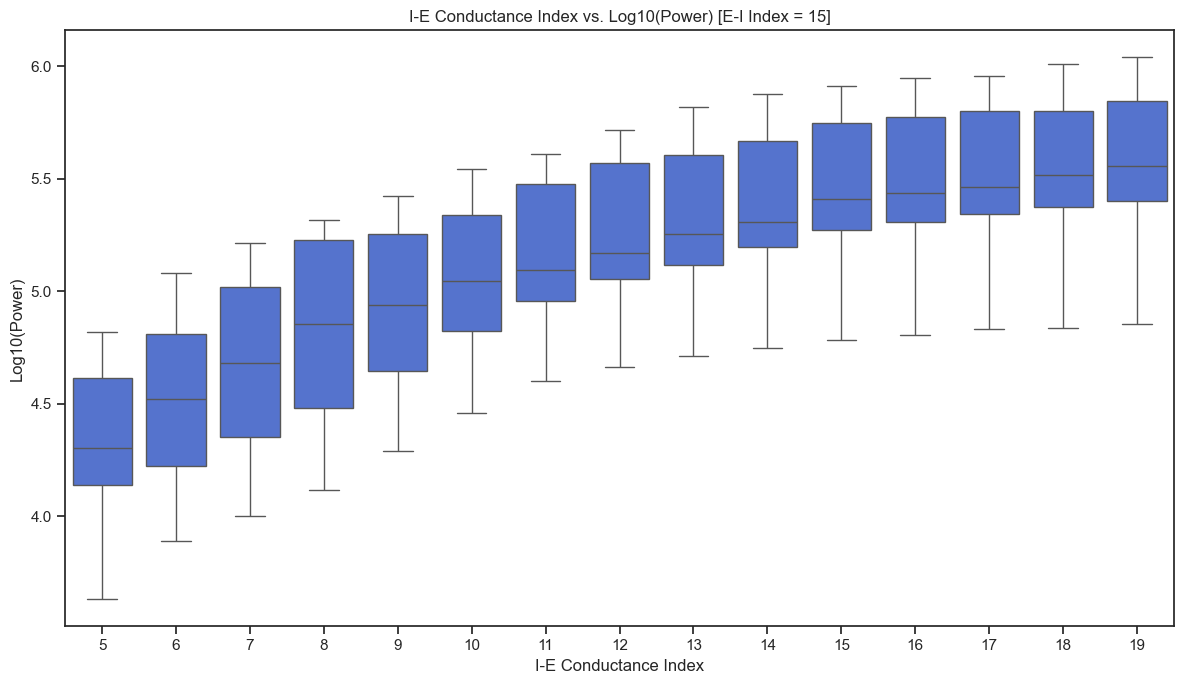

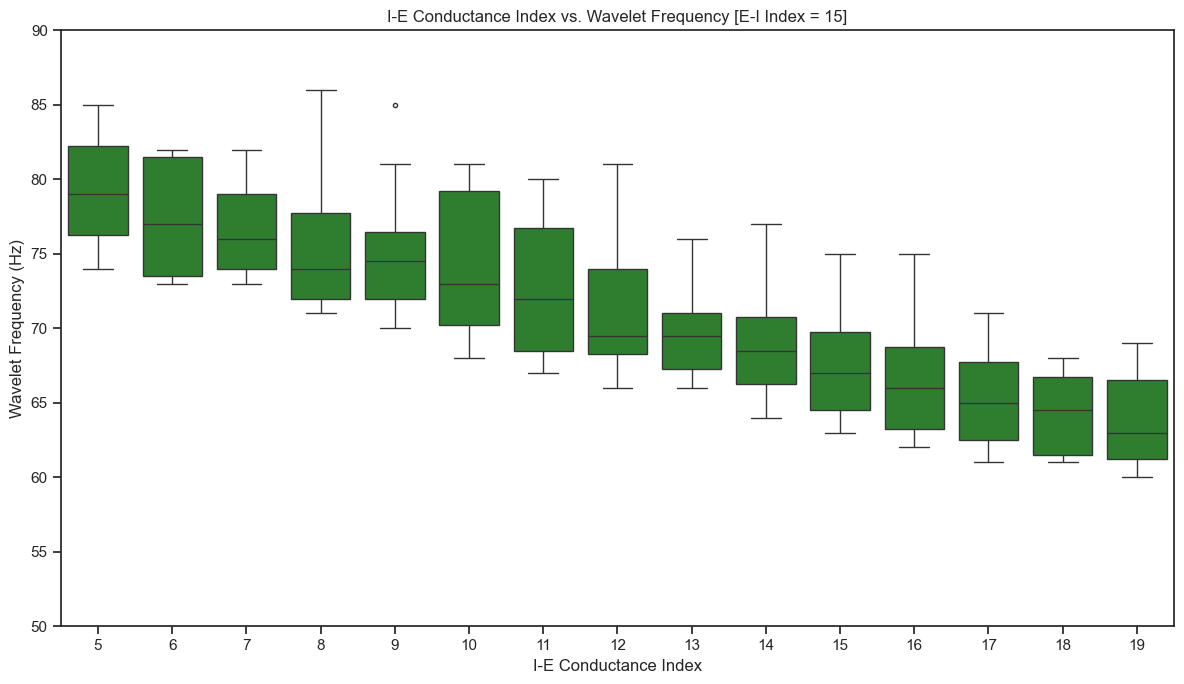

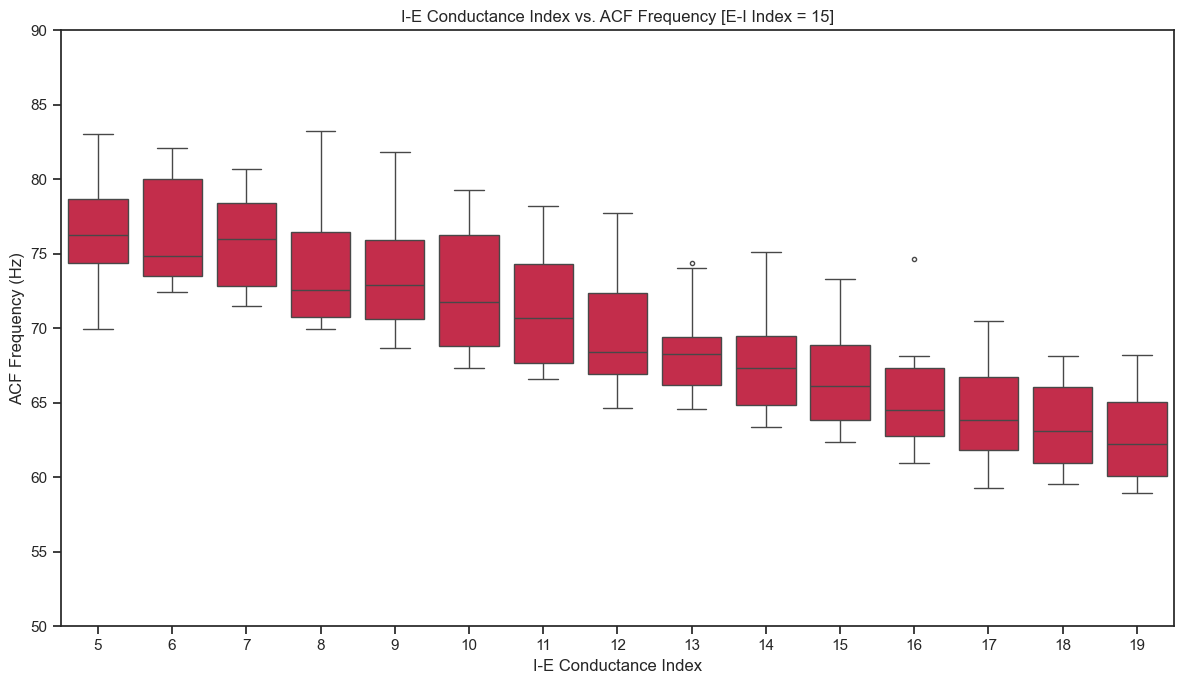

Analysis complete. Figures saved as .png and .eps in the current directory.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def analyze_and_plot_ie_slice(excel_file_path):
    """
    Reads the full 2D parameter sweep data, slices it for a fixed E-I index, 
    applies strict confidence filters, and generates box plots for the I-E sweep.
    """
    column_names = ['Seed', 'EI_Index', 'IE_Index', 'Power', 'Wavelet_Freq', 'ACF_Freq']
    
    try:
        # 1. Read the Excel file with the 6 specific columns
        df = pd.read_excel(excel_file_path, header=None, names=column_names, usecols=[0, 1, 2, 3, 4, 5])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print(f"Error: File not found at {excel_file_path}")
        return
    except Exception as e:
        print(f"Error reading Excel file: {e}")
        return

    # 2. Data Cleaning
    for col in column_names:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna()
    initial_count = len(df)

    # --- 3. THE FILTERS ---
    # Filter A: Fix E-I Index at 15 to get our 1D slice
    df = df[df['EI_Index'] == 15]
    print(f"Sliced data for EI_Index = 15. {len(df)} rows remain.")

    # Filter B: Drop I-E indices below 5 (non-oscillatory)
    df = df[df['IE_Index'] >= 5]
    
    # Filter C: Strict <= 10 Hz difference between Wavelet and ACF
    df['Freq_Diff'] = (df['Wavelet_Freq'] - df['ACF_Freq']).abs()
    df = df[df['Freq_Diff'] <= 10]
    
    print(f"Filters applied (IE >= 5, Diff <= 10Hz). Retained {len(df)} highly confident rows for plotting.")

    # 4. Handle Power for Log10 Transformation
    df['Power'] = df['Power'].apply(lambda x: x if x > 0 else np.nan)
    df = df.dropna(subset=['Power'])
    df['LogPower'] = np.log10(df['Power'])

    # Set overall visual style for Seaborn
    sns.set_theme(style="ticks") 

    # --- Plot 1: I-E Index vs Log10(Power) ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='IE_Index', y='LogPower', color='royalblue', fliersize=3)
    plt.title('I-E Conductance Index vs. Log10(Power) [E-I Index = 15]')
    plt.xlabel('I-E Conductance Index')
    plt.ylabel('Log10(Power)')
    plt.tight_layout()
    plt.savefig('0714_Slice_IE_vs_LogPower.png', dpi=300)
    plt.savefig('0714_Slice_IE_vs_LogPower.eps', format='eps')
    plt.show()

    # --- Plot 2: I-E Index vs Wavelet Frequency ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='IE_Index', y='Wavelet_Freq', color='forestgreen', fliersize=3)
    plt.title('I-E Conductance Index vs. Wavelet Frequency [E-I Index = 15]')
    plt.xlabel('I-E Conductance Index')
    plt.ylabel('Wavelet Frequency (Hz)')
    plt.ylim([50, 90])
    plt.tight_layout()
    plt.savefig('0714_Slice_IE_vs_WaveletFreq.png', dpi=300)
    plt.savefig('0714_Slice_IE_vs_WaveletFreq.eps', format='eps')
    plt.show()

    # --- Plot 3: I-E Index vs ACF Frequency ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='IE_Index', y='ACF_Freq', color='crimson', fliersize=3)
    plt.title('I-E Conductance Index vs. ACF Frequency [E-I Index = 15]')
    plt.xlabel('I-E Conductance Index')
    plt.ylabel('ACF Frequency (Hz)')
    plt.ylim([50, 90])
    plt.tight_layout()
    plt.savefig('0714_Slice_IE_vs_ACFFreq.png', dpi=300)
    plt.savefig('0714_Slice_IE_vs_ACFFreq.eps', format='eps')
    plt.show()

    print("Analysis complete. Figures saved as .png and .eps in the current directory.")


if __name__ == "__main__":
    excel_file_path = '0711_GEGI_Data_All.xlsx' 
    analyze_and_plot_ie_slice(excel_file_path)